# Hypothesis Testing & Product Monetization Analysis
## Conversion Rate Optimization & Revenue Impact Evaluation

### Objective
Evaluate the statistical significance and business impact of the monetization experiment on Conversion Rate (CR) and Average Revenue Per User (ARPU).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from scipy import stats

# Load dataset
df = pd.read_csv('../data/ab_test_monetization_raw.csv')

# Separate control and treatment cohorts
control = df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

### 1. Primary Conversion Metric Analysis (Two-Sample Z-Test)
* $H_0: CR_{\text{treatment}} = CR_{\text{control}}$
* $H_1: CR_{\text{treatment}} \neq CR_{\text{control}}$

In [2]:
conv_control = control['converted'].sum()
n_control = len(control)
cr_control = conv_control / n_control

conv_treatment = treatment['converted'].sum()
n_treatment = len(treatment)
cr_treatment = conv_treatment / n_treatment

# Proportions Z-Test
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])
z_stat, p_val_cr = proportions_ztest(count, nobs, alternative='two-sided')

# Confidence interval for difference in proportions
ci_low, ci_high = confint_proportions_2indep(conv_treatment, n_treatment, conv_control, n_control, method='wald')
relative_uplift_cr = ((cr_treatment - cr_control) / cr_control) * 100

print(f"Control Conversion Rate:   {cr_control * 100:.2f}% ({conv_control:,} / {n_control:,})")
print(f"Treatment Conversion Rate: {cr_treatment * 100:.2f}% ({conv_treatment:,} / {n_treatment:,})")
print(f"Relative Uplift:           {relative_uplift_cr:+.2f}%")
print(f"Absolute Difference 95% CI: [{ci_low * 100:+.3f}%, {ci_high * 100:+.3f}%]")
print(f"Z-statistic:               {z_stat:.4f}")
print(f"p-value:                   {p_val_cr:.4e}")

Control Conversion Rate:   5.07% (1,269.0 / 25,053)
Treatment Conversion Rate: 6.16% (1,536.0 / 24,947)
Relative Uplift:           +21.55%
Absolute Difference 95% CI: [+0.688%, +1.495%]
Z-statistic:               5.3046
p-value:                   1.1295e-07


### 2. Monetization & Revenue Metric Analysis (ARPU & Bootstrap Simulation)
Since revenue per user has a zero-inflated, heavy right-tail distribution, we apply Welch's T-Test alongside non-parametric Bootstrap Resampling (10,000 iterations).

In [3]:
arpu_control = control['revenue'].mean()
arpu_treatment = treatment['revenue'].mean()
arpu_diff = arpu_treatment - arpu_control
relative_uplift_arpu = (arpu_diff / arpu_control) * 100

# Welch's T-test (does not assume equal variances)
t_stat, p_val_arpu = stats.ttest_ind(treatment['revenue'], control['revenue'], equal_var=False)

# Bootstrap Resampling for ARPU Difference
np.random.seed(42)
n_boot = 10000
boot_control = np.random.choice(control['revenue'], size=(n_boot, len(control)), replace=True).mean(axis=1)
boot_treatment = np.random.choice(treatment['revenue'], size=(n_boot, len(treatment)), replace=True).mean(axis=1)
boot_diffs = boot_treatment - boot_control

ci_arpu_low, ci_arpu_high = np.percentile(boot_diffs, [2.5, 97.5])

print(f"Control ARPU:              ${arpu_control:.3f}")
print(f"Treatment ARPU:            ${arpu_treatment:.3f}")
print(f"Absolute ARPU Difference:  ${arpu_diff:+.3f}")
print(f"Relative ARPU Uplift:      {relative_uplift_arpu:+.2f}%")
print(f"ARPU Diff 95% Bootstrap CI: [${ci_arpu_low:+.3f}, ${ci_arpu_high:+.3f}]")
print(f"Welch's t-statistic:       {t_stat:.4f}")
print(f"p-value (Revenue):         {p_val_arpu:.4e}")

Control ARPU:              $1.683
Treatment ARPU:            $1.548
Absolute ARPU Difference:  $-0.134
Relative ARPU Uplift:      -7.99%
ARPU Diff 95% Bootstrap CI: [$-0.257, $-0.013]
Welch's t-statistic:       -2.1502
p-value (Revenue):         3.1546e-02


### 3. Business Decision Visualizations
Visualizing the bootstrap distribution of the ARPU difference and conversion rates.

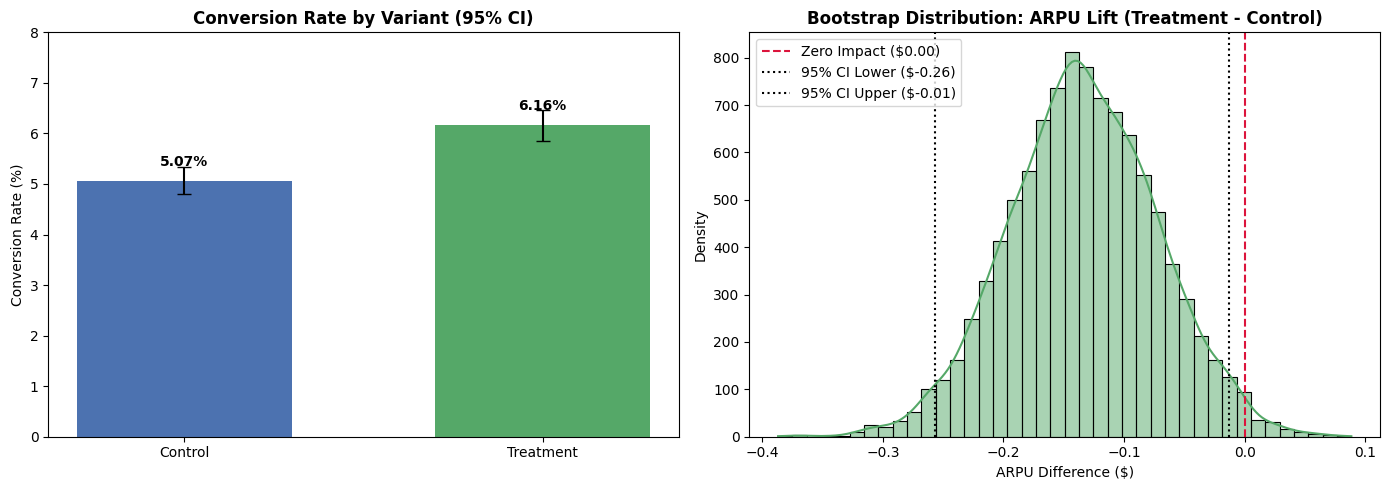

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Conversion Rate with 95% CI error bars
cr_data = pd.DataFrame({
    'Variant': ['Control', 'Treatment'],
    'Conversion Rate (%)': [cr_control * 100, cr_treatment * 100],
    'Error': [
        1.96 * np.sqrt((cr_control * (1 - cr_control)) / n_control) * 100,
        1.96 * np.sqrt((cr_treatment * (1 - cr_treatment)) / n_treatment) * 100
    ]
})
axes[0].bar(cr_data['Variant'], cr_data['Conversion Rate (%)'], yerr=cr_data['Error'], capsize=5, color=['#4C72B0', '#55A868'], width=0.6)
axes[0].set_title('Conversion Rate by Variant (95% CI)', weight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 8.0)
for i, v in enumerate(cr_data['Conversion Rate (%)']):
    axes[0].text(i, v + 0.3, f"{v:.2f}%", ha='center', weight='bold')

# Plot 2: Bootstrap Distribution of ARPU Difference
sns.histplot(boot_diffs, kde=True, ax=axes[1], color='#55A868', bins=40)
axes[1].axvline(x=0, color='crimson', linestyle='--', label='Zero Impact ($0.00)')
axes[1].axvline(x=ci_arpu_low, color='black', linestyle=':', label=f'95% CI Lower (${ci_arpu_low:.2f})')
axes[1].axvline(x=ci_arpu_high, color='black', linestyle=':', label=f'95% CI Upper (${ci_arpu_high:.2f})')
axes[1].set_title('Bootstrap Distribution: ARPU Lift (Treatment - Control)', weight='bold')
axes[1].set_xlabel('ARPU Difference ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/monetization_results_summary.png', dpi=300)
plt.show()